# LEGO 1xN Constraint Visualization

This notebook visualizes the constraint points for the LEGO 1xN brick problem.

**Constraints:**
- **Outside envelope (red)**: Points where SDF should be positive (no material)
- **Inside envelope (blue)**: Points where material CAN exist
- **Interface (green)**: Stud tops and sides where SDF = 0 with outward normals
- **Walls (magenta)**: Six faces of the brick body (bottom, top, four sides) where SDF = 0 with outward normals

In [1]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.set_default_device('cpu')
print("Imports complete")

Imports complete


In [2]:
from GINN.problems.problem_lego_1xN import ProblemLego1xN

# Create a 1x4 LEGO brick
problem = ProblemLego1xN(
    nx=3,
    n_studs=4,
    n_points_envelope=2000,
    n_points_interfaces=1000,
    n_points_domain=3000
)

Created LEGO 1x4 problem (height_scale=1.00) [no_studs=cuboid only]:
  Bounds: [[-1.9874999523162842, 1.9874999523162842], [-0.48750001192092896, 0.48750001192092896], [-0.6000000238418579, 0.6000000238418579]]
  Stud centers: 0 studs
  Points: 2000 far_outside, 4000 outside, 2000 around_if, 6000 inside, 0 interface, 6 walls


In [3]:
# Get constraint points (now with SimJEB-style regions + walls)
pts_far_outside = problem.constr_pts_dict['far_outside_envelope']
pts_outside = problem.constr_pts_dict['outside_envelope']
pts_around_if = problem.constr_pts_dict['envelope_around_interface']
pts_inside = problem.constr_pts_dict['inside_envelope']
pts_interface = problem.constr_pts_dict['interface']
pts_walls = problem.constr_pts_dict['walls']  # six brick-body faces (SDF=0, outward normals)

print(f"Far outside envelope points: {pts_far_outside.shape}")
print(f"Outside envelope points: {pts_outside.shape}")
print(f"Around interface points: {pts_around_if.shape}")
print(f"Inside envelope points: {pts_inside.shape}")
print(f"Interface points (studs): {pts_interface.shape}")
print(f"Wall points (6 faces): {pts_walls.shape}")

Far outside envelope points: (666, 3)
Outside envelope points: (666, 3)
Around interface points: (666, 3)
Inside envelope points: (3000, 3)
Interface points (studs): (0, 3)
Wall points (6 faces): (996, 3)


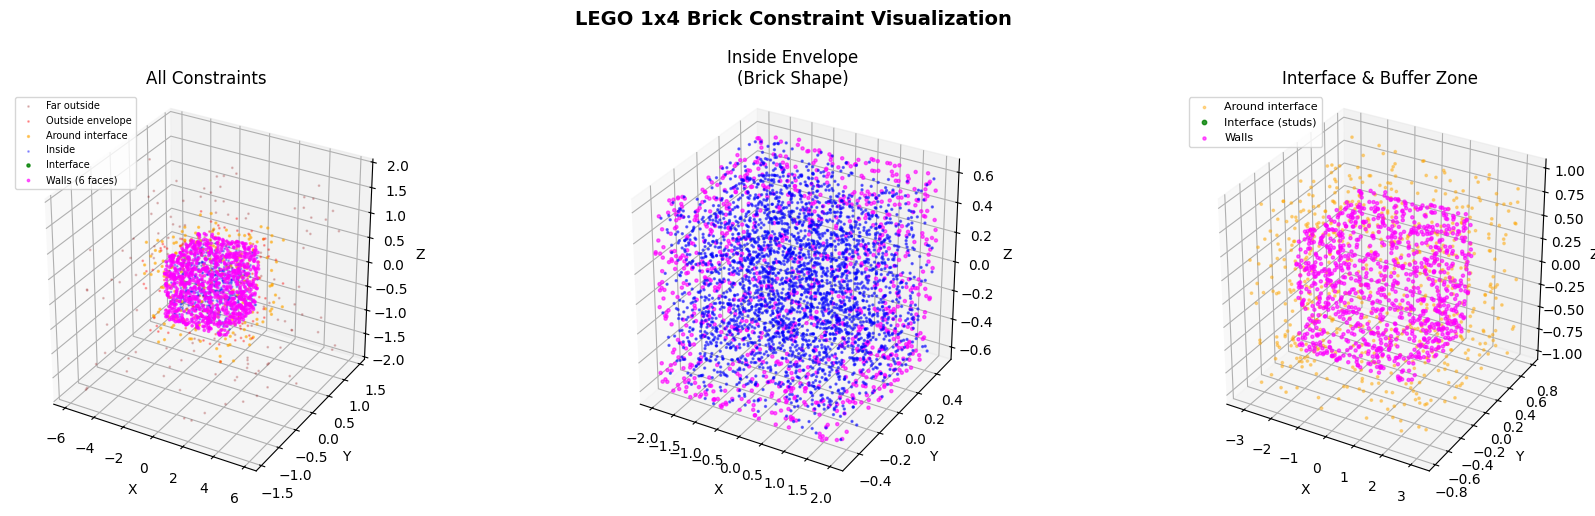

In [4]:
# Create 3D visualization with matplotlib
fig = plt.figure(figsize=(18, 5))

# Plot 1: All constraints (4 regions now)
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(pts_far_outside[::5, 0], pts_far_outside[::5, 1], pts_far_outside[::5, 2], 
            c='darkred', s=1, alpha=0.2, label='Far outside')
ax1.scatter(pts_outside[::5, 0], pts_outside[::5, 1], pts_outside[::5, 2], 
            c='red', s=1, alpha=0.3, label='Outside envelope')
ax1.scatter(pts_around_if[::3, 0], pts_around_if[::3, 1], pts_around_if[::3, 2], 
            c='orange', s=2, alpha=0.5, label='Around interface')
ax1.scatter(pts_inside[::5, 0], pts_inside[::5, 1], pts_inside[::5, 2], 
            c='blue', s=1, alpha=0.3, label='Inside')
ax1.scatter(pts_interface[:, 0], pts_interface[:, 1], pts_interface[:, 2], 
            c='green', s=5, alpha=0.8, label='Interface')
ax1.scatter(pts_walls[:, 0], pts_walls[:, 1], pts_walls[:, 2], 
            c='magenta', s=3, alpha=0.6, label='Walls (6 faces)')
ax1.set_title('All Constraints')
ax1.legend(loc='upper left', fontsize=7)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_box_aspect([1, 1, 1])

# Plot 2: Inside points only (shows brick shape)
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(pts_inside[:, 0], pts_inside[:, 1], pts_inside[:, 2], 
            c='blue', s=2, alpha=0.5)
ax2.scatter(pts_walls[:, 0], pts_walls[:, 1], pts_walls[:, 2], 
            c='magenta', s=5, alpha=0.6, label='Walls')
ax2.set_title('Inside Envelope\n(Brick Shape)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.set_box_aspect([1, 1, 1])

# Plot 3: Interface + Around Interface points
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(pts_around_if[:, 0], pts_around_if[:, 1], pts_around_if[:, 2], 
            c='orange', s=3, alpha=0.4, label='Around interface')
ax3.scatter(pts_interface[:, 0], pts_interface[:, 1], pts_interface[:, 2], 
            c='green', s=10, alpha=0.8, label='Interface (studs)')
ax3.scatter(pts_walls[:, 0], pts_walls[:, 1], pts_walls[:, 2], 
            c='magenta', s=5, alpha=0.6, label='Walls')
ax3.set_title('Interface & Buffer Zone')
ax3.legend(loc='upper left', fontsize=8)
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')
ax3.set_box_aspect([1, 1, 1])

plt.suptitle('LEGO 1x4 Brick Constraint Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3D Mesh Visualization

Generate a mesh for the LEGO brick and visualize it with the constraint points.

In [5]:
def create_lego_mesh(problem, n_theta=32):
    """Create a mesh for the LEGO brick (body + studs)."""
    import numpy as np
    
    def _f(x):
        return x.item() if hasattr(x, 'item') else float(x)
    
    vertices = []
    faces = []
    
    # Get brick dimensions from bounds
    x_min, x_max = problem.bounds[0].cpu().numpy()
    y_min, y_max = problem.bounds[1].cpu().numpy()
    z_min = problem.bounds[2, 0].cpu().numpy()
    z_body_top = _f(problem.stud_z_bottom)  # Top of body (where studs start)
    
    # ============ BRICK BODY (box) ============
    # 8 vertices for the box
    box_verts = np.array([
        [x_min, y_min, z_min],  # 0
        [x_max, y_min, z_min],  # 1
        [x_max, y_max, z_min],  # 2
        [x_min, y_max, z_min],  # 3
        [x_min, y_min, z_body_top],  # 4
        [x_max, y_min, z_body_top],  # 5
        [x_max, y_max, z_body_top],  # 6
        [x_min, y_max, z_body_top],  # 7
    ])
    vertices.extend(box_verts)
    
    # 6 faces (each as 2 triangles)
    box_faces = [
        # Bottom
        [0, 2, 1], [0, 3, 2],
        # Top (excluding stud areas - simplified, just full top)
        [4, 5, 6], [4, 6, 7],
        # Front
        [0, 1, 5], [0, 5, 4],
        # Back
        [2, 3, 7], [2, 7, 6],
        # Left
        [0, 4, 7], [0, 7, 3],
        # Right
        [1, 2, 6], [1, 6, 5],
    ]
    faces.extend(box_faces)
    
    # ============ STUDS (cylinders) ============
    stud_r = _f(problem.stud_radius)
    stud_z_top = _f(problem.stud_z_top)

    for cx, cy in problem.stud_centers:
        cx, cy = _f(cx), _f(cy)
        base_idx = len(vertices)
        
        # Create cylinder vertices
        theta = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
        
        # Bottom ring
        for t in theta:
            vertices.append([cx + stud_r * np.cos(t), cy + stud_r * np.sin(t), z_body_top])
        # Top ring
        for t in theta:
            vertices.append([cx + stud_r * np.cos(t), cy + stud_r * np.sin(t), stud_z_top])
        # Center points for caps
        vertices.append([cx, cy, z_body_top])  # Bottom center
        vertices.append([cx, cy, stud_z_top])   # Top center
        
        bottom_center = base_idx + 2 * n_theta
        top_center = base_idx + 2 * n_theta + 1
        
        # Side faces
        for i in range(n_theta):
            i_next = (i + 1) % n_theta
            # Bottom ring indices
            b0, b1 = base_idx + i, base_idx + i_next
            # Top ring indices
            t0, t1 = base_idx + n_theta + i, base_idx + n_theta + i_next
            # Two triangles per side quad
            faces.append([b0, b1, t1])
            faces.append([b0, t1, t0])
        
        # Top cap faces
        for i in range(n_theta):
            i_next = (i + 1) % n_theta
            t0, t1 = base_idx + n_theta + i, base_idx + n_theta + i_next
            faces.append([top_center, t0, t1])
        
        # Bottom cap faces (optional - these touch the body)
        # Skip for cleaner mesh, or include:
        # for i in range(n_theta):
        #     i_next = (i + 1) % n_theta
        #     b0, b1 = base_idx + i, base_idx + i_next
        #     faces.append([bottom_center, b1, b0])
    
    return np.array(vertices, dtype=np.float32), np.array(faces, dtype=np.uint32)

# Create the mesh
verts, faces = create_lego_mesh(problem)
print(f"Created LEGO mesh: {len(verts)} vertices, {len(faces)} faces")

Created LEGO mesh: 8 vertices, 12 faces


In [6]:
try:
    import k3d
    
    fig = k3d.plot(height=600)
    
    # Add the mesh
    fig += k3d.mesh(verts, faces, color=0xd35400, side='double', 
                    opacity=0.7, name='LEGO Brick')
    
    # Add constraint points
    fig += k3d.points(pts_far_outside[::3].astype(np.float32), 
                      color=0x8b0000, point_size=0.02, name='Far outside')
    fig += k3d.points(pts_outside[::3].astype(np.float32), 
                      color=0xe74c3c, point_size=0.02, name='Outside envelope')
    fig += k3d.points(pts_around_if[::2].astype(np.float32), 
                      color=0xf39c12, point_size=0.02, name='Around interface')
    fig += k3d.points(pts_inside[::3].astype(np.float32), 
                      color=0x3498db, point_size=0.02, name='Inside envelope')
    fig += k3d.points(pts_interface.astype(np.float32), 
                      color=0x2ecc71, point_size=0.03, name='Interface (studs)')
    fig += k3d.points(pts_walls.astype(np.float32), 
                      color=0x9b59b6, point_size=0.025, name='Walls (6 faces)')
    
    fig.display()
    print("Interactive 3D visualization with mesh loaded!")
    print("Toggle layers using the menu on the right.")
    
except ImportError:
    print("k3d not installed. Install with: pip install k3d")
    print("\nUsing matplotlib instead...")
    
    # Matplotlib fallback - show mesh as wireframe
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot mesh as triangles
    mesh_polys = [[verts[f[0]], verts[f[1]], verts[f[2]]] for f in faces]
    mesh_collection = Poly3DCollection(mesh_polys, alpha=0.3, facecolor='orange', 
                                         edgecolor='darkorange', linewidth=0.3)
    ax.add_collection3d(mesh_collection)
    
    # Plot constraint points
    ax.scatter(pts_interface[:, 0], pts_interface[:, 1], pts_interface[:, 2], 
               c='green', s=10, alpha=0.8, label='Interface')
    ax.scatter(pts_inside[::5, 0], pts_inside[::5, 1], pts_inside[::5, 2], 
               c='blue', s=1, alpha=0.3, label='Inside')
    
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('LEGO Brick Mesh with Constraints')
    ax.legend()
    ax.set_box_aspect([1, 1, 1])
    plt.tight_layout()
    plt.show()

Output()

Interactive 3D visualization with mesh loaded!
Toggle layers using the menu on the right.


In [7]:
try:
    import k3d
    
    fig = k3d.plot(height=600)
    
    # Outside envelope (red)
    fig += k3d.points(pts_outside[::3].astype(np.float32), 
                      color=0xe74c3c, point_size=0.02, name='Outside envelope')
    
    # Inside envelope (blue)
    fig += k3d.points(pts_inside[::3].astype(np.float32), 
                      color=0x3498db, point_size=0.02, name='Inside envelope')
    
    # Interface - stud tops (green)
    fig += k3d.points(pts_interface.astype(np.float32), 
                      color=0x2ecc71, point_size=0.03, name='Interface (stud tops)')
    fig += k3d.points(pts_walls.astype(np.float32), 
                      color=0x9b59b6, point_size=0.025, name='Walls (6 faces)')
    
    fig.display()
    print("Interactive 3D visualization loaded!")
    
except ImportError:
    print("k3d not installed. Using matplotlib only.")
    print("Install with: pip install k3d")

Output()

Interactive 3D visualization loaded!


## Varying height (k3d)

Create 1x4 bricks with different **height_scale** (body height only; stud height fixed). Shown side-by-side in k3d so you can compare heights.

In [8]:
# Varying height: 1x4 bricks with height_scale 0.5, 1.0, 1.5 (side-by-side in k3d)
from GINN.problems.problem_lego_1xN import ProblemLego1xN

height_scales = [0.5, 1.0, 1.5]  # bigger contrast: half, nominal, 1.5x
x_offsets = [-5, 0, 5]  # side-by-side so heights are comparable
colors = [0x00bcd4, 0x2ecc71, 0xe67e22]  # cyan, green, orange
names = ['height 0.5', 'height 1.0', 'height 1.5']

try:
    import k3d
    fig = k3d.plot(height=600)
    for h_scale, x_off, color, name in zip(height_scales, x_offsets, colors, names):
        prob = ProblemLego1xN(
            nx=3, n_studs=4,
            n_points_envelope=800, n_points_interfaces=500, n_points_domain=1500,
            height_scale=h_scale
        )
        z_lo = prob.bounds[2, 0].item() if hasattr(prob.bounds[2, 0], 'item') else float(prob.bounds[2, 0])
        z_hi = prob.bounds[2, 1].item() if hasattr(prob.bounds[2, 1], 'item') else float(prob.bounds[2, 1])
        print(f'  {name}: z in [{z_lo:.4f}, {z_hi:.4f}]')
        verts, faces = create_lego_mesh(prob)
        verts = verts.copy()
        verts[:, 0] += x_off
        fig += k3d.mesh(verts.astype(np.float32), faces, color=color, side='double', opacity=0.8, name=f'{name} (mesh)')
        walls = prob.constr_pts_dict['walls'].astype(np.float32)
        interface = prob.constr_pts_dict['interface'].astype(np.float32)
        walls[:, 0] += x_off
        interface[:, 0] += x_off
        fig += k3d.points(walls, color=color, point_size=0.03, name=f'{name} (walls)')
        fig += k3d.points(interface, color=color, point_size=0.04, name=f'{name} (studs)')
    fig.display()
    print('Toggle layers on the right to compare heights.')
except ImportError:
    print('k3d not installed. pip install k3d')

Created LEGO 1x4 problem (height_scale=0.50) [no_studs=cuboid only]:
  Bounds: [[-1.9874999523162842, 1.9874999523162842], [-0.48750001192092896, 0.48750001192092896], [-0.30000001192092896, 0.30000001192092896]]
  Stud centers: 0 studs
  Points: 800 far_outside, 1600 outside, 800 around_if, 3000 inside, 0 interface, 6 walls
  height 0.5: z in [-0.3000, 0.3000]
Created LEGO 1x4 problem (height_scale=1.00) [no_studs=cuboid only]:
  Bounds: [[-1.9874999523162842, 1.9874999523162842], [-0.48750001192092896, 0.48750001192092896], [-0.6000000238418579, 0.6000000238418579]]
  Stud centers: 0 studs
  Points: 800 far_outside, 1600 outside, 800 around_if, 3000 inside, 0 interface, 6 walls
  height 1.0: z in [-0.6000, 0.6000]
Created LEGO 1x4 problem (height_scale=1.50) [no_studs=cuboid only]:
  Bounds: [[-1.9874999523162842, 1.9874999523162842], [-0.48750001192092896, 0.48750001192092896], [-0.8999999761581421, 0.8999999761581421]]
  Stud centers: 0 studs
  Points: 800 far_outside, 1600 outside

Output()

Toggle layers on the right to compare heights.


## Try Different Brick Sizes

Created LEGO 1x1 problem (height_scale=1.00) [no_studs=cuboid only]:
  Bounds: [[-0.48750001192092896, 0.48750001192092896], [-0.48750001192092896, 0.48750001192092896], [-0.6000000238418579, 0.6000000238418579]]
  Stud centers: 0 studs
  Points: 1000 far_outside, 2000 outside, 1000 around_if, 4000 inside, 0 interface, 6 walls
Created LEGO 1x2 problem (height_scale=1.00) [no_studs=cuboid only]:
  Bounds: [[-0.987500011920929, 0.987500011920929], [-0.48750001192092896, 0.48750001192092896], [-0.6000000238418579, 0.6000000238418579]]
  Stud centers: 0 studs
  Points: 1000 far_outside, 2000 outside, 1000 around_if, 4000 inside, 0 interface, 6 walls
Created LEGO 1x4 problem (height_scale=1.00) [no_studs=cuboid only]:
  Bounds: [[-1.9874999523162842, 1.9874999523162842], [-0.48750001192092896, 0.48750001192092896], [-0.6000000238418579, 0.6000000238418579]]
  Stud centers: 0 studs
  Points: 1000 far_outside, 2000 outside, 1000 around_if, 4000 inside, 0 interface, 6 walls
Created LEGO 1x8 pr

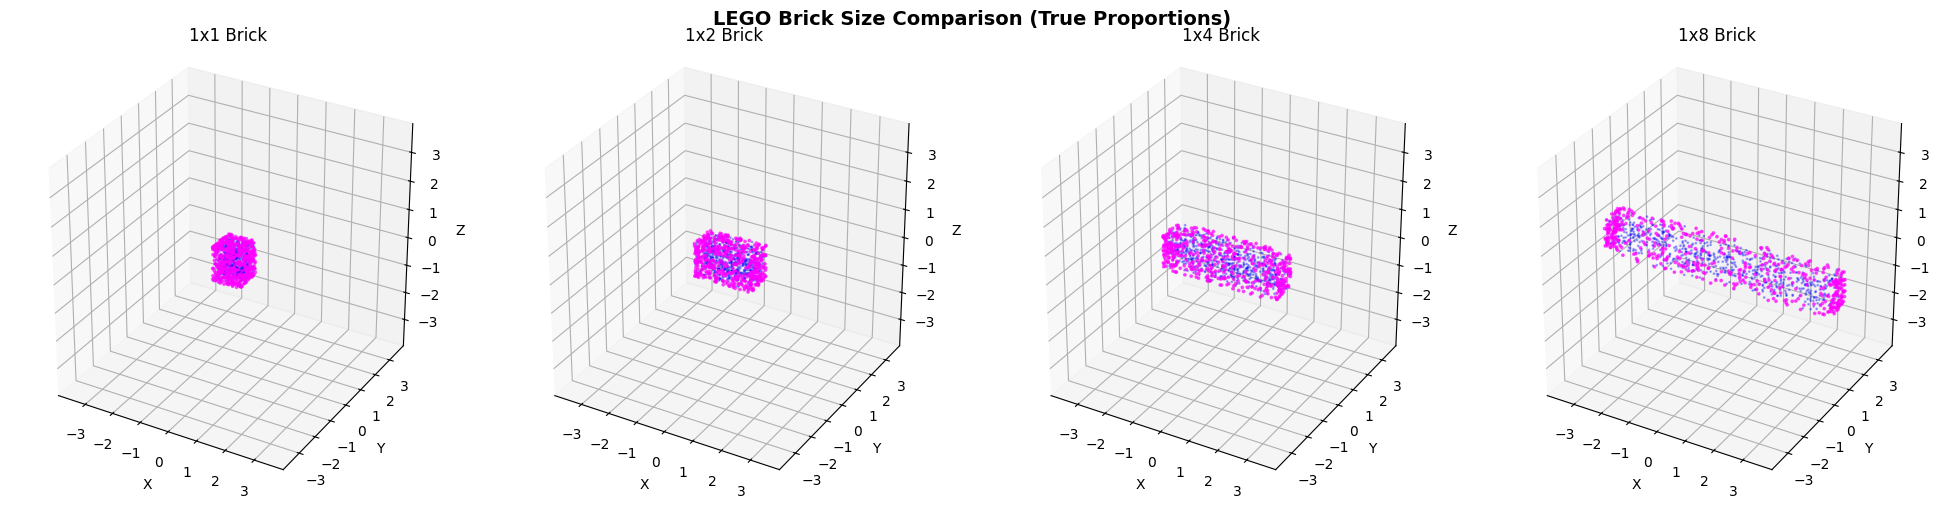

All plots use same axis limits: ±3.99
Now you can see the 1x1 is actually small and 1x8 is long!


In [9]:
# Compare different brick sizes with CORRECT aspect ratios
fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={'projection': '3d'})

# Find the max extent across all bricks to set consistent limits
all_probs = []
max_extent = 0

for i, n_studs in enumerate([1, 2, 4, 8]):
    prob = ProblemLego1xN(
        nx=3,
        n_studs=n_studs,
        n_points_envelope=1000,
        n_points_interfaces=500,
        n_points_domain=2000
    )
    all_probs.append(prob)
    
    # Track max extent for consistent scaling
    x_range = prob.bounds[0, 1] - prob.bounds[0, 0]
    max_extent = max(max_extent, x_range.item())

# Now plot with consistent aspect ratio
for i, (n_studs, prob) in enumerate(zip([1, 2, 4, 8], all_probs)):
    pts = prob.constr_pts_dict['inside_envelope']
    interface = prob.constr_pts_dict['interface']
    walls = prob.constr_pts_dict['walls']
    
    ax = axes[i]
    ax.scatter(pts[::3, 0], pts[::3, 1], pts[::3, 2], c='blue', s=1, alpha=0.3)
    ax.scatter(interface[:, 0], interface[:, 1], interface[:, 2], c='green', s=5, alpha=0.8)
    ax.scatter(walls[:, 0], walls[:, 1], walls[:, 2], c='magenta', s=3, alpha=0.6)
    ax.set_title(f'1x{n_studs} Brick')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # Set equal aspect ratio - use the same limits for all plots
    half_extent = max_extent / 2
    ax.set_xlim(-half_extent, half_extent)
    ax.set_ylim(-half_extent, half_extent)
    ax.set_zlim(-half_extent, half_extent)
    
    # Make axes equal scale (requires matplotlib 3.3+)
    ax.set_box_aspect([1, 1, 1])

plt.suptitle('LEGO Brick Size Comparison (True Proportions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"All plots use same axis limits: ±{half_extent:.2f}")
print("Now you can see the 1x1 is actually small and 1x8 is long!")

## NxN bricks

Same problem supports **NxN** (grid of studs): pass `n_studs_y=N` to get an N×N brick. Example: 2×2, 3×3, 4×4.

Created LEGO 2x2 problem (height_scale=1.00) [no_studs=cuboid only]:
  Bounds: [[-0.987500011920929, 0.987500011920929], [-0.987500011920929, 0.987500011920929], [-0.6000000238418579, 0.6000000238418579]]
  Stud centers: 0 studs
  Points: 1000 far_outside, 2000 outside, 1000 around_if, 4000 inside, 0 interface, 6 walls


AssertionError: Expected 4 studs for 2x2

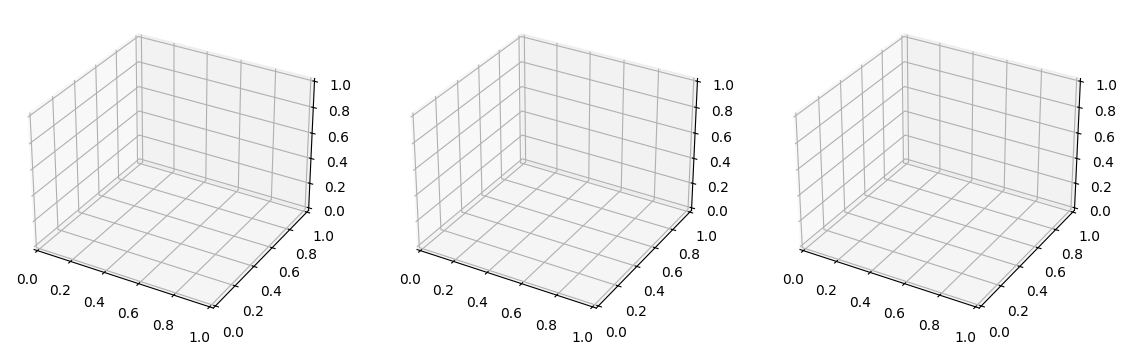

In [10]:
# NxN bricks: 2x2, 3x3, 4x4 (pass n_studs_y=N to get NxN grid of studs)
import importlib
import GINN.problems.problem_lego_1xN as _lego_mod
importlib.reload(_lego_mod)  # ensure latest NxN support is loaded
from GINN.problems.problem_lego_1xN import ProblemLego1xN

fig, axes = plt.subplots(1, 3, subplot_kw={'projection': '3d'}, figsize=(14, 5))
for idx, N in enumerate([2, 3, 4]):
    prob = ProblemLego1xN(
        nx=3, n_studs=N, n_studs_y=N,  # NxN grid (not 1xN)
        n_points_envelope=1000, n_points_interfaces=500, n_points_domain=2000
    )
    # NxN should have N*N studs (e.g. 2x2 -> 4 studs)
    assert len(prob.stud_centers) == N * N, f"Expected {N*N} studs for {N}x{N}"
    pts = prob.constr_pts_dict['inside_envelope']
    interface = prob.constr_pts_dict['interface']
    walls = prob.constr_pts_dict['walls']
    ax = axes[idx]
    ax.scatter(pts[::3, 0], pts[::3, 1], pts[::3, 2], c='blue', s=1, alpha=0.3)
    ax.scatter(interface[:, 0], interface[:, 1], interface[:, 2], c='green', s=5, alpha=0.8)
    ax.scatter(walls[:, 0], walls[:, 1], walls[:, 2], c='magenta', s=3, alpha=0.6)
    ax.set_title(f'{N}x{N} Brick')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    half = max(prob.bounds[0, 1].item() - prob.bounds[0, 0].item(), prob.bounds[1, 1].item() - prob.bounds[1, 0].item()) / 2
    ax.set_xlim(-half, half); ax.set_ylim(-half, half); ax.set_zlim(-half, half)
plt.suptitle('NxN LEGO bricks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# NxN bricks in k3d (interactive): 2x2, 3x3, 4x4 side-by-side. Run the cell that defines create_lego_mesh first.
import importlib
import GINN.problems.problem_lego_1xN as _lego_mod
importlib.reload(_lego_mod)
from GINN.problems.problem_lego_1xN import ProblemLego1xN

try:
    import k3d
    fig = k3d.plot(height=600)
    sizes = [2, 3, 4]
    x_offsets = [-6, 0, 6]
    colors = [0x3498db, 0x2ecc71, 0xe74c3c]  # blue, green, red
    for N, x_off, color in zip(sizes, x_offsets, colors):
        prob = ProblemLego1xN(
            nx=3, n_studs=N, n_studs_y=N,  # NxN grid (not 1xN)
            n_points_envelope=800, n_points_interfaces=500, n_points_domain=1500
        )
        verts, faces = create_lego_mesh(prob)
        verts = verts.copy()
        verts[:, 0] += x_off
        fig += k3d.mesh(verts.astype(np.float32), faces, color=color, side='double', opacity=0.85, name=f'{N}x{N} (mesh)')
        walls = prob.constr_pts_dict['walls'].astype(np.float32)
        interface = prob.constr_pts_dict['interface'].astype(np.float32)
        walls[:, 0] += x_off
        interface[:, 0] += x_off
        fig += k3d.points(walls, color=color, point_size=0.025, name=f'{N}x{N} (walls)')
        fig += k3d.points(interface, color=color, point_size=0.035, name=f'{N}x{N} (studs)')
    fig.display()
    print('NxN bricks in k3d: toggle layers on the right to show/hide meshes and constraint points.')
except ImportError:
    print('k3d not installed. pip install k3d')

Created LEGO 2x2 problem (height_scale=1.00):
  Bounds: [[-0.987500011920929, 0.987500011920929], [-0.987500011920929, 0.987500011920929], [-0.7124999761581421, 0.7124999761581421]]
  Stud centers: 4 studs
  Points: 800 far_outside, 1600 outside, 800 around_if, 3000 inside, 496 interface, 6 walls
Created LEGO 3x3 problem (height_scale=1.00):
  Bounds: [[-1.4874999523162842, 1.4874999523162842], [-1.4874999523162842, 1.4874999523162842], [-0.7124999761581421, 0.7124999761581421]]
  Stud centers: 9 studs
  Points: 800 far_outside, 1600 outside, 800 around_if, 3000 inside, 486 interface, 6 walls
Created LEGO 4x4 problem (height_scale=1.00):
  Bounds: [[-1.9874999523162842, 1.9874999523162842], [-1.9874999523162842, 1.9874999523162842], [-0.7124999761581421, 0.7124999761581421]]
  Stud centers: 16 studs
  Points: 800 far_outside, 1600 outside, 800 around_if, 3000 inside, 480 interface, 6 walls


Output()

NxN bricks in k3d: toggle layers on the right to show/hide meshes and constraint points.


## All variations: 1×N, N×N, and height

One view of **all** possible variations: brick size (1×2, 1×4, 2×2, 4×4) × height scale (0.5, 1.0, 1.5). Arranged in a grid: columns = brick type, rows = height.

In [ ]:
# All variations: 1xN, NxN × height. Run the cell that defines create_lego_mesh first.
import importlib
import GINN.problems.problem_lego_1xN as _lego_mod
importlib.reload(_lego_mod)
from GINN.problems.problem_lego_1xN import ProblemLego1xN

try:
    import k3d
    # Brick types: (label, n_studs, n_studs_y) — None = 1xN
    brick_configs = [
        ('1x2', 2, None), ('1x4', 4, None), ('2x2', 2, 2), ('4x4', 4, 4)
    ]
    height_scales = [0.5, 1.0, 1.5]
    x_spacing, z_spacing = 7, 5  # grid spacing
    colors = [0x3498db, 0x2ecc71, 0xe74c3c, 0x9b59b6]  # blue, green, red, purple per brick type

    fig = k3d.plot(height=700)
    for col, (label, n_studs, n_studs_y) in enumerate(brick_configs):
        for row, h_scale in enumerate(height_scales):
            prob = ProblemLego1xN(
                nx=3, n_studs=n_studs, n_studs_y=n_studs_y,
                n_points_envelope=500, n_points_interfaces=300, n_points_domain=1000,
                height_scale=h_scale
            )
            verts, faces = create_lego_mesh(prob)
            verts = verts.copy()
            verts[:, 0] += col * x_spacing
            verts[:, 2] += row * z_spacing
            color = colors[col % len(colors)]
            name = f'{label} h={h_scale}'
            fig += k3d.mesh(verts.astype(np.float32), faces, color=color, side='double', opacity=0.85, name=name)
    fig.display()
    print('Grid: columns = 1x2, 1x4, 2x2, 4x4 | rows = height 0.5, 1.0, 1.5')
except ImportError:
    print('k3d not installed. pip install k3d')

Created LEGO 1x2 problem (height_scale=0.50):
  Bounds: [[-0.987500011920929, 0.987500011920929], [-0.48750001192092896, 0.48750001192092896], [-0.4124999940395355, 0.4124999940395355]]
  Stud centers: 2 studs
  Points: 500 far_outside, 1000 outside, 500 around_if, 2000 inside, 300 interface, 6 walls
Created LEGO 1x2 problem (height_scale=1.00):
  Bounds: [[-0.987500011920929, 0.987500011920929], [-0.48750001192092896, 0.48750001192092896], [-0.7124999761581421, 0.7124999761581421]]
  Stud centers: 2 studs
  Points: 500 far_outside, 1000 outside, 500 around_if, 2000 inside, 300 interface, 6 walls
Created LEGO 1x2 problem (height_scale=1.50):
  Bounds: [[-0.987500011920929, 0.987500011920929], [-0.48750001192092896, 0.48750001192092896], [-1.0125000476837158, 1.0125000476837158]]
  Stud centers: 2 studs
  Points: 500 far_outside, 1000 outside, 500 around_if, 2000 inside, 300 interface, 6 walls
Created LEGO 1x4 problem (height_scale=0.50):
  Bounds: [[-1.9874999523162842, 1.9874999523162

Output()

Grid: columns = 1x2, 1x4, 2x2, 4x4 | rows = height 0.5, 1.0, 1.5


## Examine Bounds and Stud Locations

In [ ]:
# Print geometric info
print("=" * 50)
print("LEGO 1x4 Brick Geometry")
print("=" * 50)
print(f"\nBounds (normalized):")
print(f"  X: [{problem.bounds[0, 0]:.3f}, {problem.bounds[0, 1]:.3f}]")
print(f"  Y: [{problem.bounds[1, 0]:.3f}, {problem.bounds[1, 1]:.3f}]")
print(f"  Z: [{problem.bounds[2, 0]:.3f}, {problem.bounds[2, 1]:.3f}]")

print(f"\nStud geometry:")
print(f"  Radius: {problem.stud_radius:.3f}")
print(f"  Z range: [{problem.stud_z_bottom:.3f}, {problem.stud_z_top:.3f}]")
print(f"  Centers (x, y):")
for i, (cx, cy) in enumerate(problem.stud_centers):
    print(f"    Stud {i+1}: ({cx:.3f}, {cy:.3f})")

print(f"\nScale factor: {problem.scale_factor:.4f}")

LEGO 1x4 Brick Geometry

Bounds (normalized):
  X: [-1.987, 1.987]
  Y: [-0.488, 0.488]
  Z: [-0.712, 0.712]

Stud geometry:
  Radius: 0.300
  Z range: [0.487, 0.713]
  Centers (x, y):
    Stud 1: (-1.488, 0.000)
    Stud 2: (-0.488, 0.000)
    Stud 3: (0.512, 0.000)
    Stud 4: (1.512, 0.000)

Scale factor: 0.1250
